# **Photogrammetric Computation by Programming**

**2108627 Geoimage Processing (Graduated Student Course)**

Thepchai Srinoi

Department of Survey Engineering

Faculty of Engineering

Chulalongkorn University

Install Library

In [ ]:
!pip install rasterio

Download Aerial Photograph DMC0683 DMC0684

In [ ]:
!gdown 1ANrgP9evpdNsYUSnNjMgFhnzuZfdkrGE

Downloading...
From (original): https://drive.google.com/uc?id=1ANrgP9evpdNsYUSnNjMgFhnzuZfdkrGE
From (redirected): https://drive.google.com/uc?id=1ANrgP9evpdNsYUSnNjMgFhnzuZfdkrGE&confirm=t&uuid=f2e4f00d-6ef0-4469-bcef-d63f548f118b
To: /content/dmc_0683BW_32647.tif
100% 106M/106M [00:03<00:00, 31.2MB/s]


In [ ]:
!gdown 1UASR1p0yIWSedeL4liKmmU0SGgw70O0G

Downloading...
From (original): https://drive.google.com/uc?id=1UASR1p0yIWSedeL4liKmmU0SGgw70O0G
From (redirected): https://drive.google.com/uc?id=1UASR1p0yIWSedeL4liKmmU0SGgw70O0G&confirm=t&uuid=8eb74fa1-70a0-4b51-b514-9c7d0d6c3012
To: /content/dmc_0684BW_32647.tif
100% 106M/106M [00:00<00:00, 119MB/s]


In [ ]:
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np

Visualize Stereopair Photograph

In [ ]:
with rio.open('/content/dmc_0683BW_32647.tif') as src1:
    img1 = src1.read(1)  # First band

with rio.open('/content/dmc_0684BW_32647.tif') as src2:
    img2 = src2.read(1)

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


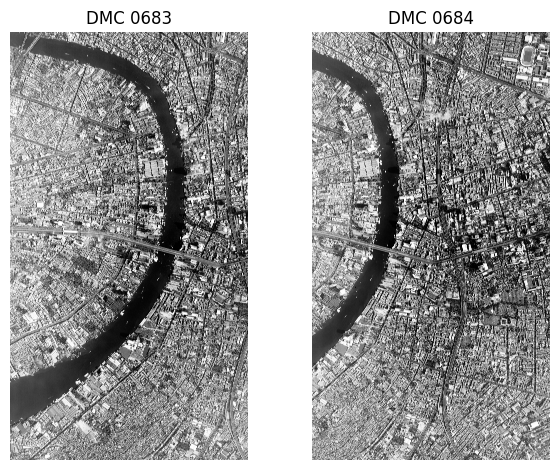

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(img1 , 'gray')
plt.title('DMC 0683')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2 , 'gray')
plt.title('DMC 0684')
plt.axis('off')

plt.tight_layout()
plt.show()

Interior Orientation Transformation

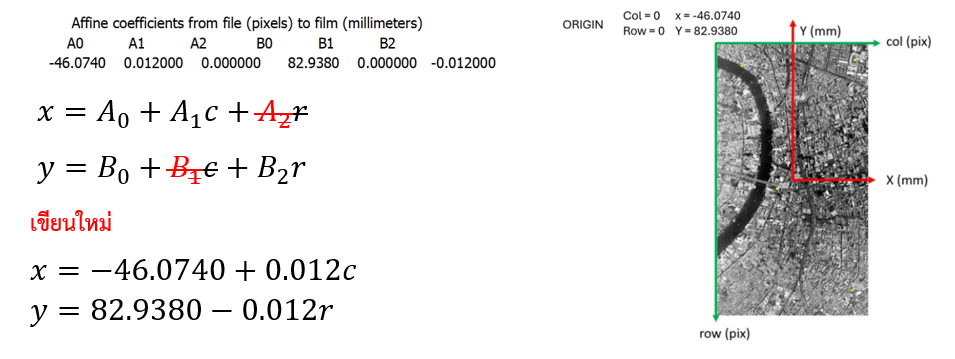

col,row to x,y

In [ ]:
# Transformation Parameter file (pix) to film (mm)
A0 = -46.0740
A1 = 0.012
A2 = 0
B0 = 82.9380
B1 = 0
B2 = -0.012

In [ ]:
# DMC0684 A01 A02 A04 A05
uv = np.array([  [ 6993.73, 791.99],
                 [ 6874.36, 12544.81 ],
                 [ 1243.26, 1083.69 ] ,
                 [ 3041.50, 7355.44 ]       ])
col = uv[:,0]
row = uv[:,1]

x = A0 + A1*col + A2*row
y = B0 + B1*col + B2*row

## x y in unit mm ... convert to m

x = np.array( [x/1000] ).T
y = np.array( [y/1000] ).T

xy = np.concatenate( (x, y), axis=1)        # m
xy

array([[ 0.03785076,  0.07343412],
       [ 0.03641832, -0.06759972],
       [-0.03115488,  0.06993372],
       [-0.009576  , -0.00532728]])

x,y to col,row

In [ ]:
# Affine Transformation Parameter from film (mm) to file (pix)
a = A1
b = A2
c = A0
d = B1
e = B2
f = B0

low = a*e - b*d

ap = e/low
bp = -b/low
cp = (b*f - c*e)/low
dp = -d/low
ep = a/low
fp = (c*d - f*a)/low

In [ ]:
# DMC0684 A01 A02 A04 A05
xy = np.array([ [ 0.03785076,  0.07343412],
                [ 0.03641832, -0.06759972],
                [-0.03115488,  0.06993372],
                [-0.009576  , -0.00532728]  ])*1000

x = xy[:,0]
y = xy[:,1]

U = cp + x*ap + y*bp
V = fp + x*dp  + y*ep

## x y in unit mm ... convert to m

U = np.array( [U] ).T
V = np.array( [V] ).T

UV = np.concatenate( (U, V), axis=1)        # m
UV

array([[ 6993.73,   791.99],
       [ 6874.36, 12544.81],
       [ 1243.26,  1083.69],
       [ 3041.5 ,  7355.44]])

Colinearity Equations

In [ ]:
# Rotation Matrix
def RotMatrix(ome, phi, kap) :
    coso = np.cos(ome)
    sino = np.sin(ome)
    cosp = np.cos(phi)
    sinp = np.sin(phi)
    cosk = np.cos(kap)
    sink = np.sin(kap)


    m11 = cosp*cosk
    m12 = coso*sink + sino*sinp*cosk
    m13 = sino*sink - coso*sinp*cosk
    m21 = -1*cosp*sink
    m22 = coso*cosk - sino*sinp*sink
    m23 =  sino*cosk + coso*sinp*sink
    m31 = sinp
    m32 = -1*sino*cosp
    m33 = coso*cosp
    return m11, m12, m13, m21, m22, m23, m31, m32, m33

# Estimated Functional Matrix
def Colinearity( obj_coord , EOP , f ) :

    X, Y, Z = ( float(val) for val in obj_coord.A1 )
    X0,Y0,Z0,ome,phi,kap = ( float(val) for val in EOP.A1 )

    m11, m12, m13, m21, m22, m23, m31, m32, m33 = RotMatrix(ome, phi, kap)

    U = m11*(X - X0) + m12*(Y - Y0) + m13*(Z - Z0)
    V = m21*(X - X0) + m22*(Y - Y0) + m23*(Z - Z0)
    W = m31*(X - X0) + m32*(Y - Y0) + m33*(Z - Z0)

    F1 = -f*(U/W)
    F2 = -f*(V/W)

    F = np.matrix([F1, F2]).T
    return F

In [ ]:
# DMC0684 A01 A02 A04 A05

ground = np.matrix([ [664982.199, 1519200.444, 2.379],
                    [665012.917, 1515481.931, 2.533],
                    [663119.106, 1519141.009, 2.767],
                    [663762.254, 1517085.614, 2.757]  ])

obj_coord_all = ground.flatten().T

f = 120*1e-3

# EOP Estimation... GPS AT

X0 = 664232.206
Y0 = 1517208.639
Z0 = 3224.199
om = np.radians( 0.46356 )
ph = np.radians( 3.79589 )
kp = np.radians( 1.16223 )

eop = np.matrix([X0, Y0, Z0, om, ph, kp]).T



In [ ]:
n = 0

## convert from ground coordinate to photo coordinate

XX = obj_coord_all[3*n:3*n+3,:]
F = Colinearity(XX , eop , f )
x,y = ( float(val) for val in F.A1 )

## convert photo coordinate from m to mm
x = x*1000
y = y*1000

print('Photo Coordinate x y (mm)')
print(x, y)
## convert from photo coordinate to pixel coordinate
c = ap*x + bp*y + cp
r = dp*x + ep*y + fp
print('Pixel Coordinate c r (pix)')
print(c, r)

Photo Coordinate x y (mm)
37.81257208028033 73.39942558175136
Pixel Coordinate c r (pix)
6990.547673356694 794.8812015207204


**Spatial Resection**

DMC 0683 (3 GCPs)

In [ ]:
n_par = 6
d = 1

photo = np.matrix([ [ -41.13 , -66.78 ],
                   [ 2.63 , 70.63 ],
                   [ 24.64 , -6.31 ]])*1e-3

Lb = photo.flatten().T
n_obs = len( Lb )

ground = np.matrix([ [662028.637, 1515376.869, 2.416],
                    [663119.106, 1519141.009, 2.767],
                    [663762.254, 1517085.614, 2.757]  ])

obj_coord_all = ground.flatten().T

f = 120*1e-3

# EOP Estimation

X0 = 663000
Y0 = 1517000
Z0 = 3200
om = np.radians( 0 )
ph = np.radians( 4 )
kp = np.radians( 0 )

eop = np.matrix([X0, Y0, Z0, om, ph, kp]).T

print('initial exterior parameter')
print(eop)

for l in range(7) :
    print('================================')
    print('LOOP =', l )
    Fk = np.zeros([n_obs,1])
    Jk = np.zeros([n_obs, n_par])

    for n in range( int(n_obs/2) ) :
        XX = obj_coord_all[3*n:3*n+3,:]

        # Estimated Function Value
        F = Colinearity(XX , eop , f )

        Fk[2*n:2*n+2,:] = F

        delta = d
        deltaA = np.radians( d )

        # Form Jacobian Matrix
        Fc1 = Colinearity(XX , eop + np.matrix([delta,0,0,0,0,0]).T, f )
        Fc2 = Colinearity(XX , eop + np.matrix([0,delta,0,0,0,0]).T, f )
        Fc3 = Colinearity(XX , eop + np.matrix([0,0,delta,0,0,0]).T, f )
        Fc4 = Colinearity(XX , eop + np.matrix([0,0,0,deltaA,0,0]).T, f )
        Fc5 = Colinearity(XX , eop + np.matrix([0,0,0,0,deltaA,0]).T, f )
        Fc6 = Colinearity(XX , eop + np.matrix([0,0,0,0,0,deltaA]).T, f )

        J1 = (Fc1 - F)/delta
        J2 = (Fc2 - F)/delta
        J3 = (Fc3 - F)/delta
        J4 = (Fc4 - F)/deltaA
        J5 = (Fc5 - F)/deltaA
        J6 = (Fc6 - F)/deltaA

        J = np.concatenate( (J1, J2, J3, J4, J5, J6) , axis = 1)

        Jk[2*n:2*n+2,:] = J


    # Least Square Adjustment
    Fk = np.matrix(Fk)
    Lb = np.matrix(Lb)
    Jk = np.matrix(Jk)

    A = Jk
    L = Fk - Lb


    N = np.matmul(A.transpose(), A)
    uu = np.matmul(A.transpose(), L)
    iN = np.linalg.inv(N)
    dX = -1*np.matmul(iN, uu)

    eop += dX


    print(' loop difference ')
    print( 'dX0    ', dX[0].item() , 'm' )
    print( 'dY0    ', dX[1].item() , 'm')
    print( 'dZ0    ', dX[2].item() , 'm')
    print( 'dOmega', np.degrees( dX[3].item() ), 'deg' )
    print( 'dPhi  ', np.degrees(dX[4].item() ) , 'deg')
    print( 'dKappa', np.degrees(dX[5].item() ) , 'deg')

    v = np.matmul(A,dX) + L

print(' Exterior Orientation ')
print( 'X    ', eop[0].item() , 'm' )
print( 'Y    ', eop[1].item() , 'm')
print( 'Z    ', eop[2].item() , 'm')
print( 'Omega', np.degrees( eop[3].item() ), 'deg' )
print( 'Phi  ', np.degrees(eop[4].item() ) , 'deg')
print( 'Kappa', np.degrees(eop[5].item() ) , 'deg')

initial exterior parameter
[[6.63000000e+05]
 [1.51700000e+06]
 [3.20000000e+03]
 [0.00000000e+00]
 [6.98131701e-02]
 [0.00000000e+00]]
LOOP = 0
 loop difference 
dX0     309.51042907554074 m
dY0     197.55405808173964 m
dZ0     15.80818578671824 m
dOmega 0.4265929934107688 deg
dPhi   -0.36664515627084804 deg
dKappa 1.6281571811159832 deg
LOOP = 1
 loop difference 
dX0     -2.212744208807635 m
dY0     15.801376256344838 m
dZ0     6.03661353059249 m
dOmega -0.05199787522164249 deg
dPhi   0.0007197082835928316 deg
dKappa -0.007206490798084432 deg
LOOP = 2
 loop difference 
dX0     0.11929015462494341 m
dY0     -0.0001325911674592284 m
dZ0     0.0212773268109423 m
dOmega 0.000493205467045967 deg
dPhi   0.002126918505838846 deg
dKappa -1.4658020437129012e-05 deg
LOOP = 3
 loop difference 
dX0     0.0038713524257709686 m
dY0     -0.0017468213216882272 m
dZ0     -0.002702478091909828 m
dOmega 2.9644797009613763e-05 deg
dPhi   6.913568134921397e-05 deg
dKappa 1.7579182366282075e-06 deg
LOOP =

DMC 0684

In [ ]:
n_par = 6
d = 1

photo = np.matrix([ [ 37.85,  73.43],
                   [ 36.43, -67.60],
                   [-31.16,  69.93],
                   [ -9.58,    -5.33]  ])*1e-3

Lb = photo.flatten().T
n_obs = len( Lb )

ground = np.matrix([ [664982.199, 1519200.444, 2.379],
                    [665012.917, 1515481.931, 2.533],
                    [663119.106, 1519141.009, 2.767],
                    [663762.254, 1517085.614, 2.757]  ])

obj_coord_all = ground.flatten().T

f = 120*1e-3

# EOP Estimation

X0 = 664000
Y0 = 1517000
Z0 = 3200
om = np.radians( 0 )
ph = np.radians( 4 )
kp = np.radians( 0 )

eop = np.matrix([X0, Y0, Z0, om, ph, kp]).T

print('initial exterior parameter')
print(eop)

for l in range(5) :
    print('================================')
    print('LOOP =', l )
    Fk = np.zeros([n_obs,1])
    Jk = np.zeros([n_obs, n_par])

    for n in range( int(n_obs/2) ) :
        XX = obj_coord_all[3*n:3*n+3,:]

        # Estimated Function Value
        F = Colinearity(XX , eop , f )

        Fk[2*n:2*n+2,:] = F

        delta = d
        deltaA = np.radians( d )

        # Form Jacobian Matrix
        Fc1 = Colinearity(XX , eop + np.matrix([delta,0,0,0,0,0]).T, f )
        Fc2 = Colinearity(XX , eop + np.matrix([0,delta,0,0,0,0]).T, f )
        Fc3 = Colinearity(XX , eop + np.matrix([0,0,delta,0,0,0]).T, f )
        Fc4 = Colinearity(XX , eop + np.matrix([0,0,0,deltaA,0,0]).T, f )
        Fc5 = Colinearity(XX , eop + np.matrix([0,0,0,0,deltaA,0]).T, f )
        Fc6 = Colinearity(XX , eop + np.matrix([0,0,0,0,0,deltaA]).T, f )

        J1 = (Fc1 - F)/delta
        J2 = (Fc2 - F)/delta
        J3 = (Fc3 - F)/delta
        J4 = (Fc4 - F)/deltaA
        J5 = (Fc5 - F)/deltaA
        J6 = (Fc6 - F)/deltaA

        J = np.concatenate( (J1, J2, J3, J4, J5, J6) , axis = 1)

        Jk[2*n:2*n+2,:] = J


    # Least Square Adjustment
    Fk = np.matrix(Fk)
    Lb = np.matrix(Lb)
    Jk = np.matrix(Jk)

    A = Jk
    L = Fk - Lb


    N = np.matmul(A.transpose(), A)
    uu = np.matmul(A.transpose(), L)
    iN = np.linalg.inv(N)
    dX = -1*np.matmul(iN, uu)

    eop += dX


    print(' loop difference ')
    print( 'dX0    ', dX[0].item() , 'm' )
    print( 'dY0    ', dX[1].item() , 'm')
    print( 'dZ0    ', dX[2].item() , 'm')
    print( 'dOmega', np.degrees( dX[3].item() ), 'deg' )
    print( 'dPhi  ', np.degrees(dX[4].item() ) , 'deg')
    print( 'dKappa', np.degrees(dX[5].item() ) , 'deg')

    v = np.matmul(A,dX) + L


    SSE = np.matmul(v.transpose(), v).item()
    RMSE = np.sqrt( SSE/( len(Lb) - 6 ) )

    print('***********')
    print('RMSE = ', RMSE)

print(' Exterior Orientation ')
print( 'X    ', eop[0].item() , 'm' )
print( 'Y    ', eop[1].item() , 'm')
print( 'Z    ', eop[2].item() , 'm')
print( 'Omega', np.degrees( eop[3].item() ), 'deg' )
print( 'Phi  ', np.degrees(eop[4].item() ) , 'deg')
print( 'Kappa', np.degrees(eop[5].item() ) , 'deg')

initial exterior parameter
[[6.64000000e+05]
 [1.51700000e+06]
 [3.20000000e+03]
 [0.00000000e+00]
 [6.98131701e-02]
 [0.00000000e+00]]
LOOP = 0
 loop difference 
dX0     238.12665439948432 m
dY0     204.05180241046395 m
dZ0     19.324158344026728 m
dOmega 0.4151094164874156 deg
dPhi   -0.13368647992490004 deg
dKappa 1.178885891644467 deg
***********
RMSE =  5.598778915052239e-06
LOOP = 1
 loop difference 
dX0     -6.279345016366932 m
dY0     4.8960959909436355 m
dZ0     2.8957859320187698 m
dOmega 0.04709017684522304 deg
dPhi   -0.07457113782160824 deg
dKappa -0.008091113268511627 deg
***********
RMSE =  4.900684601508877e-06
LOOP = 2
 loop difference 
dX0     0.011301423416015175 m
dY0     -0.01708538902074835 m
dZ0     -0.0073448849479824255 m
dOmega 0.0002803812494960708 deg
dPhi   0.00013112469427216348 deg
dKappa 0.0002430227324198976 deg
***********
RMSE =  4.389387964291316e-06
LOOP = 3
 loop difference 
dX0     5.441368211206747e-05 m
dY0     -8.553039203081385e-06 m
dZ0     -

**Spatial Intersection**

In [ ]:
n_par = 3
d = 1

'''
photo = np.matrix([ [ 16.729,  81.928],
                    [ -17.641,  81.113] ])*1e-3
'''
photo = np.matrix([ [ 36.13 ,  -66.55 ],
                    [  1.81,  -64.37 ] ])*1e-3

Lb = photo.flatten().T
n_obs = len( Lb )


f = 120*1e-3


# EOP 0683

X0_L = 663307.594
Y0_L = 1517213.529
Z0_L = 3221.403
om_L = 0.006473 #np.radians( 0.37213 )
ph_L = 0.063495 #np.radians( 3.63363 )
kp_L = 0.028343 #np.radians( 1.62283 )

eop1 = np.matrix([X0_L, Y0_L, Z0_L, om_L, ph_L, kp_L]).T

#My Least Square 63
X0_R = 664232.022
Y0_R = 1517209.093
Z0_R = 3222.474
om_R = 0.008052 #np.radians( 0.45831 )
ph_R = 0.066204 #np.radians( 3.79946 )
kp_R = 0.020480 #np.radians( 1.17540 )
eop2 = np.matrix([X0_R, Y0_R, Z0_R, om_R, ph_R, kp_R]).T


# Estimated Point Cloud Coordinate

Xpc = 663000.0
Ypc = 1517000
Zpc = 0
XX = np.matrix( [Xpc, Ypc, Zpc] ).T

In [ ]:
for l in range(5) :
    print('================================')
    print('LOOP =', l )
    Fk = np.zeros([n_obs,1])
    Jk = np.zeros([n_obs, n_par])

    # Estimated Function Value
    FL = Colinearity(XX , eop1 , f )
    Fk[0:2,:] = FL

    FR = Colinearity(XX , eop2 , f )
    Fk[2:4,:] = FR

    delta = d

    # Form Jacobian Matrix
    FL1 = Colinearity(XX+ np.matrix([delta,0,0]).T , eop1 , f )
    FL2 = Colinearity(XX+ np.matrix([0,delta,0]).T , eop1 , f )
    FL3 = Colinearity(XX+ np.matrix([0,0,delta]).T , eop1 , f )

    FR1 = Colinearity(XX+ np.matrix([delta,0,0]).T , eop2 , f )
    FR2 = Colinearity(XX+ np.matrix([0,delta,0]).T , eop2 , f )
    FR3 = Colinearity(XX+ np.matrix([0,0,delta]).T , eop2 , f )

    JL1 = (FL1 - FL)/delta
    JL2 = (FL2 - FL)/delta
    JL3 = (FL3 - FL)/delta

    JR1 = (FR1 - FR)/delta
    JR2 = (FR2 - FR)/delta
    JR3 = (FR3 - FR)/delta

    #print('Jacobian Matrix')

    JkL = np.concatenate( (JL1, JL2, JL3) , axis = 1)
    JkR = np.concatenate( (JR1, JR2, JR3) , axis = 1)
    Jk = np.concatenate( (JkL, JkR) , axis = 0)


    # Least Square Adjustment
    Fk = np.matrix(Fk)
    Lb = np.matrix(Lb)
    Jk = np.matrix(Jk)

    A = Jk
    L = Fk - Lb
    print('Computed Minus Observed')
    print(L)

    N = np.matmul(A.transpose(), A)
    uu = np.matmul(A.transpose(), L)
    iN = np.linalg.inv(N)
    dX = -1*np.matmul(iN, uu)

    XX += dX


    print(' loop difference ')
    print( 'dX    ', dX[0].item() , 'm' )
    print( 'dY    ', dX[1].item() , 'm')
    print( 'dZ    ', dX[2].item() , 'm')

    v = np.matmul(A,dX) + L


    SSE = np.matmul(v.transpose(), v).item()
    RMSE = np.sqrt( SSE/( len(Lb) - n_par ) )

    print('***********')
    print('RMSE = ', RMSE)

print(' Object Coordinate ')
print( 'X    ', XX[0].item() , 'm' )
print( 'Y    ', XX[1].item() , 'm')
print( 'Z    ', XX[2].item() , 'm')

LOOP = 0
Computed Minus Observed
[[-0.0401855 ]
 [ 0.05796203]
 [-0.03898685]
 [ 0.05657041]]
 loop difference 
dX     1131.8387188016154 m
dY     -1524.7584254708531 m
dZ     -1.2026783489456372 m
***********
RMSE =  1.5298729469683844e-05
LOOP = 1
Computed Minus Observed
[[ 0.00102447]
 [-0.00149054]
 [ 0.00104339]
 [-0.00150361]]
 loop difference 
dX     -28.606171338891848 m
dY     40.3481976019308 m
dZ     4.658190545694247 m
***********
RMSE =  3.0508789771121575e-05
LOOP = 2
Computed Minus Observed
[[ 6.35480316e-07]
 [ 2.26065085e-05]
 [-2.11960245e-06]
 [-2.05585597e-05]]
 loop difference 
dX     0.021609020686852866 m
dY     -0.030277001616853896 m
dZ     0.000825982506389706 m
***********
RMSE =  3.056778408289414e-05
LOOP = 3
Computed Minus Observed
[[ 1.44898357e-06]
 [ 2.13800564e-05]
 [-1.33735275e-06]
 [-2.17576325e-05]]
 loop difference 
dX     1.522266897783703e-07 m
dY     1.399456053404199e-06 m
dZ     2.7212894663208343e-06 m
***********
RMSE =  3.056778453509669e-

**Aerial Triangulation - Block Bundle Adjustment**

In [ ]:
# Don't forget to convert from mm to m ... 1st Img GCP TP .. then 2nd Img GCP TP ...
# GCP04 GCP05 (both img) ... GCP03 (add left) ... GCP02 GCP 01 (add right)

'''
ARRANGEMENT OF OBSERVATION DATA

LEFT IMAGE
A04
A05
A03

P1
P2
P3
P4
P5

RIGHT IMAGE
A04
A05
A02
A01

P1
P2
P3
P4
P5
'''
############# IMAGE COORDINATE ########################################
Lb = np.matrix([  2.62776,   70.632,
                  24.63552,  -6.31224,
                  -41.1366 , -66.78024  ,

                  38.364192,   78.589212,
                  29.5743528,  49.6380948,
                  1.84758 ,    6.888204,
                   -8.68656,   -43.785996  ,
                  36.13254 ,  -66.551388,

                 -31.15488,  69.93372,
                 -9.576,    -5.32728,
                  36.41832, -67.59972 ,
                  37.85076,  73.43412,

                   3.2040792,  78.0246408,
                  -5.117328,   49.57812  ,
                  -31.5833952,   7.439502 ,
                  -41.4963372, -42.37299,
                  1.811016,  -64.375884  ])/1000
Lb = Lb.T

In [ ]:
# Function

# Interior Parameter Assume x0 = 0 y0 = 0

f = 120/1000 # mm -- m

# Estimated EOP 683


X0_L = 663311
Y0_L = 1517212
Z0_L = 3223
om_L = np.radians( 0.4 )
ph_L = np.radians( 3.7 )
kp_L = np.radians( 1.6 )

eop1 = np.matrix([X0_L, Y0_L, Z0_L, om_L, ph_L, kp_L])
eop1 = eop1.T

# Estimated EOP 684
X0_R = 664232
Y0_R = 1517209
Z0_R = 3224
om_R = np.radians( 0.5 )
ph_R = np.radians( 3.8 )
kp_R = np.radians( 1.2 )
eop2 = np.matrix([X0_R, Y0_R, Z0_R, om_R, ph_R, kp_R])
eop2 = eop2.T

# Estimated Tie Points
Xpc = 663000.0
Ypc = 1517000.0
Zpc = 0
T1 = np.matrix( [Xpc, Ypc, Zpc] ).T

Xpc = 663000.0
Ypc = 1517000.0
Zpc = 0
T2 = np.matrix( [Xpc, Ypc, Zpc] ).T

Xpc = 663000.0
Ypc = 1517000.0
Zpc = 0
T3 = np.matrix( [Xpc, Ypc, Zpc] ).T

Xpc = 663000.0
Ypc = 1517000.0
Zpc = 0
T4 = np.matrix( [Xpc, Ypc, Zpc] ).T

Xpc = 663000.0
Ypc = 1517000.0
Zpc = 0
T5 = np.matrix( [Xpc, Ypc, Zpc] ).T

############## GROUND COORDINATE OF GCP ###################
# GCP 1
XG1 = 663119.106
YG1 = 1519141.009
ZG1 = 2.767
G1 = np.matrix( [XG1, YG1, ZG1] ).T

# GCP 2
XG2 = 663762.254
YG2 = 1517085.614
ZG2 = 2.757
G2 = np.matrix( [XG2, YG2, ZG2] ).T

# GCP 3
XG3 = 665012.917
YG3 = 1515481.931
ZG3 = 2.533
G3 = np.matrix( [XG3, YG3, ZG3] ).T

# GCP 4
XG4 = 662028.637
YG4 = 1515376.869
ZG4 = 2.416
G4 = np.matrix( [XG4, YG4, ZG4] ).T

# GCP 5
XG5 = 664982.199
YG5 = 1519200.444
ZG5 = 2.379
G5 = np.matrix( [XG5, YG5, ZG5] ).T

XX = np.concatenate( ( eop1, eop2, T1, T2, T3, T4, T5) , axis = 0)

In [ ]:
def R(ome, phi, kap) :
    coso = np.cos(ome)
    sino = np.sin(ome)
    cosp = np.cos(phi)
    sinp = np.sin(phi)
    cosk = np.cos(kap)
    sink = np.sin(kap)

    m11 = cosp*cosk
    m12 = coso*sink + sino*sinp*cosk
    m13 = sino*sink - coso*sinp*cosk

    m21 = -cosp*sink
    m22 = coso*cosk - sino*sinp*sink
    m23 = sino*cosk + coso*sinp*sink

    m31 = sinp
    m32 = -sino*cosp
    m33 = coso*cosp

    return m11, m12, m13, m21, m22, m23, m31, m32, m33

# Jacobian Matrix
def OEF( obj_coord , EOP , f ) :
    X = obj_coord[0].item()
    Y = obj_coord[1].item()
    Z = obj_coord[2].item()

    X0 = EOP[0].item()
    Y0 = EOP[1].item()
    Z0 = EOP[2].item()
    ome = EOP[3].item()
    phi = EOP[4].item()
    kap = EOP[5].item()

    m11, m12, m13, m21, m22, m23, m31, m32, m33 = R(ome, phi, kap)

    U = m11*(X - X0) + m12*(Y - Y0) + m13*(Z - Z0)
    V = m21*(X - X0) + m22*(Y - Y0) + m23*(Z - Z0)
    W = m31*(X - X0) + m32*(Y - Y0) + m33*(Z - Z0)

    F1 = -f*(U/W)
    F2 = -f*(V/W)

    F = np.matrix([F1, F2]).T
    return F

In [ ]:
import math as m
for l in range(5) :
    print('================================')
    print('LOOP =', l )
    delta = 1
    #Fk = np.zeros([28,1])
    #Jk = np.zeros([28,27])
    #print('Correction Matrix')
    #print(dX)
    eop1 = XX[0:6]
    eop2 = XX[6:12]
    T1 = XX[12:15]
    T2 = XX[15:18]
    T3 = XX[18:21]
    T4 = XX[21:24]
    T5 = XX[24:27]

    #print('Estimation Function')
    FG1L = OEF(G1 , eop1 , f )
    FG2L = OEF(G2 , eop1 , f )
    FG4L = OEF(G4 , eop1 , f )
    FT1L = OEF(T1 , eop1 , f )
    FT2L = OEF(T2 , eop1 , f )
    FT3L = OEF(T3 , eop1 , f )
    FT4L = OEF(T4 , eop1 , f )
    FT5L = OEF(T5 , eop1 , f )

    FG1R = OEF(G1 , eop2 , f )
    FG2R = OEF(G2 , eop2 , f )
    FG3R = OEF(G3 , eop2 , f )
    FG5R = OEF(G5 , eop2 , f )
    FT1R = OEF(T1 , eop2 , f )
    FT2R = OEF(T2 , eop2 , f )
    FT3R = OEF(T3 , eop2 , f )
    FT4R = OEF(T4 , eop2 , f )
    FT5R = OEF(T5 , eop2 , f )


    allrow = (FG1L ,  FG2L , FG4L, FT1L, FT2L, FT3L, FT4L, FT5L ,
              FG1R ,  FG2R , FG3R, FG5R, FT1R, FT2R, FT3R, FT4R, FT5R  )

    Fk = np.concatenate( allrow , axis=0)


    #delta = 1

    # Left Image
    FG1Ld_X0 = OEF(G1 , eop1+ np.matrix([delta,0,0,0,0,0]).T , f )
    FG1Ld_Y0 = OEF(G1 , eop1+ np.matrix([0,delta,0,0,0,0]).T , f )
    FG1Ld_Z0 = OEF(G1 , eop1+ np.matrix([0,0,delta,0,0,0]).T , f )
    FG1Ld_O0 = OEF(G1 , eop1+ np.matrix([0,0,0,delta,0,0]).T , f )
    FG1Ld_P0 = OEF(G1 , eop1+ np.matrix([0,0,0,0,delta,0]).T , f )
    FG1Ld_K0 = OEF(G1 , eop1+ np.matrix([0,0,0,0,0,delta]).T , f )

    FG2Ld_X0 = OEF(G2 , eop1+ np.matrix([delta,0,0,0,0,0]).T , f )
    FG2Ld_Y0 = OEF(G2 , eop1+ np.matrix([0,delta,0,0,0,0]).T , f )
    FG2Ld_Z0 = OEF(G2 , eop1+ np.matrix([0,0,delta,0,0,0]).T , f )
    FG2Ld_O0 = OEF(G2 , eop1+ np.matrix([0,0,0,delta,0,0]).T , f )
    FG2Ld_P0 = OEF(G2 , eop1+ np.matrix([0,0,0,0,delta,0]).T , f )
    FG2Ld_K0 = OEF(G2 , eop1+ np.matrix([0,0,0,0,0,delta]).T , f )


    FG4Ld_X0 = OEF(G4 , eop1+ np.matrix([delta,0,0,0,0,0]).T , f )
    FG4Ld_Y0 = OEF(G4 , eop1+ np.matrix([0,delta,0,0,0,0]).T , f )
    FG4Ld_Z0 = OEF(G4 , eop1+ np.matrix([0,0,delta,0,0,0]).T , f )
    FG4Ld_O0 = OEF(G4 , eop1+ np.matrix([0,0,0,delta,0,0]).T , f )
    FG4Ld_P0 = OEF(G4 , eop1+ np.matrix([0,0,0,0,delta,0]).T , f )
    FG4Ld_K0 = OEF(G4 , eop1+ np.matrix([0,0,0,0,0,delta]).T , f )

    FT1Ld_X0 = OEF(T1 , eop1+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT1Ld_Y0 = OEF(T1 , eop1+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT1Ld_Z0 = OEF(T1 , eop1+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT1Ld_O0 = OEF(T1 , eop1+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT1Ld_P0 = OEF(T1 , eop1+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT1Ld_K0 = OEF(T1 , eop1+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT1Ld_XT = OEF(T1+ np.matrix([delta,0,0]).T  , eop1, f )
    FT1Ld_YT = OEF(T1+ np.matrix([0,delta,0]).T  , eop1, f )
    FT1Ld_ZT = OEF(T1+ np.matrix([0,0,delta]).T  , eop1, f )

    FT2Ld_X0 = OEF(T2 , eop1+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT2Ld_Y0 = OEF(T2 , eop1+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT2Ld_Z0 = OEF(T2 , eop1+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT2Ld_O0 = OEF(T2 , eop1+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT2Ld_P0 = OEF(T2 , eop1+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT2Ld_K0 = OEF(T2 , eop1+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT2Ld_XT = OEF(T2+ np.matrix([delta,0,0]).T  , eop1, f )
    FT2Ld_YT = OEF(T2+ np.matrix([0,delta,0]).T  , eop1, f )
    FT2Ld_ZT = OEF(T2+ np.matrix([0,0,delta]).T  , eop1, f )

    FT3Ld_X0 = OEF(T3 , eop1+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT3Ld_Y0 = OEF(T3 , eop1+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT3Ld_Z0 = OEF(T3 , eop1+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT3Ld_O0 = OEF(T3 , eop1+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT3Ld_P0 = OEF(T3 , eop1+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT3Ld_K0 = OEF(T3 , eop1+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT3Ld_XT = OEF(T3+ np.matrix([delta,0,0]).T  , eop1, f )
    FT3Ld_YT = OEF(T3+ np.matrix([0,delta,0]).T  , eop1, f )
    FT3Ld_ZT = OEF(T3+ np.matrix([0,0,delta]).T  , eop1, f )

    FT4Ld_X0 = OEF(T4 , eop1+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT4Ld_Y0 = OEF(T4 , eop1+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT4Ld_Z0 = OEF(T4 , eop1+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT4Ld_O0 = OEF(T4 , eop1+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT4Ld_P0 = OEF(T4 , eop1+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT4Ld_K0 = OEF(T4 , eop1+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT4Ld_XT = OEF(T4+ np.matrix([delta,0,0]).T  , eop1, f )
    FT4Ld_YT = OEF(T4+ np.matrix([0,delta,0]).T  , eop1, f )
    FT4Ld_ZT = OEF(T4+ np.matrix([0,0,delta]).T  , eop1, f )

    FT5Ld_X0 = OEF(T5 , eop1+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT5Ld_Y0 = OEF(T5 , eop1+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT5Ld_Z0 = OEF(T5 , eop1+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT5Ld_O0 = OEF(T5 , eop1+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT5Ld_P0 = OEF(T5 , eop1+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT5Ld_K0 = OEF(T5 , eop1+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT5Ld_XT = OEF(T5+ np.matrix([delta,0,0]).T  , eop1, f )
    FT5Ld_YT = OEF(T5+ np.matrix([0,delta,0]).T  , eop1, f )
    FT5Ld_ZT = OEF(T5+ np.matrix([0,0,delta]).T  , eop1, f )


    # Right Image
    FG1Rd_X0 = OEF(G1 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FG1Rd_Y0 = OEF(G1 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FG1Rd_Z0 = OEF(G1 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FG1Rd_O0 = OEF(G1 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FG1Rd_P0 = OEF(G1 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FG1Rd_K0 = OEF(G1 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )

    FG2Rd_X0 = OEF(G2 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FG2Rd_Y0 = OEF(G2 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FG2Rd_Z0 = OEF(G2 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FG2Rd_O0 = OEF(G2 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FG2Rd_P0 = OEF(G2 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FG2Rd_K0 = OEF(G2 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )

    FG3Rd_X0 = OEF(G3 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FG3Rd_Y0 = OEF(G3 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FG3Rd_Z0 = OEF(G3 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FG3Rd_O0 = OEF(G3 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FG3Rd_P0 = OEF(G3 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FG3Rd_K0 = OEF(G3 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )

    FG5Rd_X0 = OEF(G5 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FG5Rd_Y0 = OEF(G5 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FG5Rd_Z0 = OEF(G5 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FG5Rd_O0 = OEF(G5 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FG5Rd_P0 = OEF(G5 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FG5Rd_K0 = OEF(G5 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )

    FT1Rd_X0 = OEF(T1 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT1Rd_Y0 = OEF(T1 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT1Rd_Z0 = OEF(T1 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT1Rd_O0 = OEF(T1 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT1Rd_P0 = OEF(T1 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT1Rd_K0 = OEF(T1 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT1Rd_XT = OEF(T1+ np.matrix([delta,0,0]).T  , eop2, f )
    FT1Rd_YT = OEF(T1+ np.matrix([0,delta,0]).T  , eop2, f )
    FT1Rd_ZT = OEF(T1+ np.matrix([0,0,delta]).T  , eop2, f )

    FT2Rd_X0 = OEF(T2 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT2Rd_Y0 = OEF(T2 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT2Rd_Z0 = OEF(T2 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT2Rd_O0 = OEF(T2 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT2Rd_P0 = OEF(T2 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT2Rd_K0 = OEF(T2 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT2Rd_XT = OEF(T2+ np.matrix([delta,0,0]).T  , eop2, f )
    FT2Rd_YT = OEF(T2+ np.matrix([0,delta,0]).T  , eop2, f )
    FT2Rd_ZT = OEF(T2+ np.matrix([0,0,delta]).T  , eop2, f )

    FT3Rd_X0 = OEF(T3 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT3Rd_Y0 = OEF(T3 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT3Rd_Z0 = OEF(T3 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT3Rd_O0 = OEF(T3 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT3Rd_P0 = OEF(T3 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT3Rd_K0 = OEF(T3 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT3Rd_XT = OEF(T3+ np.matrix([delta,0,0]).T  , eop2, f )
    FT3Rd_YT = OEF(T3+ np.matrix([0,delta,0]).T  , eop2, f )
    FT3Rd_ZT = OEF(T3+ np.matrix([0,0,delta]).T  , eop2, f )

    FT4Rd_X0 = OEF(T4 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT4Rd_Y0 = OEF(T4 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT4Rd_Z0 = OEF(T4 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT4Rd_O0 = OEF(T4 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT4Rd_P0 = OEF(T4 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT4Rd_K0 = OEF(T4 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT4Rd_XT = OEF(T4+ np.matrix([delta,0,0]).T  , eop2, f )
    FT4Rd_YT = OEF(T4+ np.matrix([0,delta,0]).T  , eop2, f )
    FT4Rd_ZT = OEF(T4+ np.matrix([0,0,delta]).T  , eop2, f )

    FT5Rd_X0 = OEF(T5 , eop2+ np.matrix([delta,0,0,0,0,0]).T , f )
    FT5Rd_Y0 = OEF(T5 , eop2+ np.matrix([0,delta,0,0,0,0]).T , f )
    FT5Rd_Z0 = OEF(T5 , eop2+ np.matrix([0,0,delta,0,0,0]).T , f )
    FT5Rd_O0 = OEF(T5 , eop2+ np.matrix([0,0,0,delta,0,0]).T , f )
    FT5Rd_P0 = OEF(T5 , eop2+ np.matrix([0,0,0,0,delta,0]).T , f )
    FT5Rd_K0 = OEF(T5 , eop2+ np.matrix([0,0,0,0,0,delta]).T , f )
    FT5Rd_XT = OEF(T5+ np.matrix([delta,0,0]).T  , eop2, f )
    FT5Rd_YT = OEF(T5+ np.matrix([0,delta,0]).T  , eop2, f )
    FT5Rd_ZT = OEF(T5+ np.matrix([0,0,delta]).T  , eop2, f )


    # Difference Function Jacobian Matrix

    dFG1Ld_X0 = FG1Ld_X0 - FG1L
    dFG1Ld_Y0 = FG1Ld_Y0 - FG1L
    dFG1Ld_Z0 = FG1Ld_Z0 - FG1L
    dFG1Ld_O0 = FG1Ld_O0 - FG1L
    dFG1Ld_P0 = FG1Ld_P0 - FG1L
    dFG1Ld_K0 = FG1Ld_K0 - FG1L

    dFG2Ld_X0 = FG2Ld_X0 - FG2L
    dFG2Ld_Y0 = FG2Ld_Y0 - FG2L
    dFG2Ld_Z0 = FG2Ld_Z0 - FG2L
    dFG2Ld_O0 = FG2Ld_O0 - FG2L
    dFG2Ld_P0 = FG2Ld_P0 - FG2L
    dFG2Ld_K0 = FG2Ld_K0 - FG2L

    dFG4Ld_X0 = FG4Ld_X0 - FG4L
    dFG4Ld_Y0 = FG4Ld_Y0 - FG4L
    dFG4Ld_Z0 = FG4Ld_Z0 - FG4L
    dFG4Ld_O0 = FG4Ld_O0 - FG4L
    dFG4Ld_P0 = FG4Ld_P0 - FG4L
    dFG4Ld_K0 = FG4Ld_K0 - FG4L

    dFT1Ld_X0 = FT1Ld_X0 - FT1L
    dFT1Ld_Y0 = FT1Ld_Y0 - FT1L
    dFT1Ld_Z0 = FT1Ld_Z0 - FT1L
    dFT1Ld_O0 = FT1Ld_O0 - FT1L
    dFT1Ld_P0 = FT1Ld_P0 - FT1L
    dFT1Ld_K0 = FT1Ld_K0 - FT1L
    dFT1Ld_XT = FT1Ld_XT - FT1L
    dFT1Ld_YT = FT1Ld_YT - FT1L
    dFT1Ld_ZT = FT1Ld_ZT - FT1L

    dFT2Ld_X0 = FT2Ld_X0 - FT2L
    dFT2Ld_Y0 = FT2Ld_Y0 - FT2L
    dFT2Ld_Z0 = FT2Ld_Z0 - FT2L
    dFT2Ld_O0 = FT2Ld_O0 - FT2L
    dFT2Ld_P0 = FT2Ld_P0 - FT2L
    dFT2Ld_K0 = FT2Ld_K0 - FT2L
    dFT2Ld_XT = FT2Ld_XT - FT2L
    dFT2Ld_YT = FT2Ld_YT - FT2L
    dFT2Ld_ZT = FT2Ld_ZT - FT2L

    dFT3Ld_X0 = FT3Ld_X0 - FT3L
    dFT3Ld_Y0 = FT3Ld_Y0 - FT3L
    dFT3Ld_Z0 = FT3Ld_Z0 - FT3L
    dFT3Ld_O0 = FT3Ld_O0 - FT3L
    dFT3Ld_P0 = FT3Ld_P0 - FT3L
    dFT3Ld_K0 = FT3Ld_K0 - FT3L
    dFT3Ld_XT = FT3Ld_XT - FT3L
    dFT3Ld_YT = FT3Ld_YT - FT3L
    dFT3Ld_ZT = FT3Ld_ZT - FT3L

    dFT4Ld_X0 = FT4Ld_X0 - FT4L
    dFT4Ld_Y0 = FT4Ld_Y0 - FT4L
    dFT4Ld_Z0 = FT4Ld_Z0 - FT4L
    dFT4Ld_O0 = FT4Ld_O0 - FT4L
    dFT4Ld_P0 = FT4Ld_P0 - FT4L
    dFT4Ld_K0 = FT4Ld_K0 - FT4L
    dFT4Ld_XT = FT4Ld_XT - FT4L
    dFT4Ld_YT = FT4Ld_YT - FT4L
    dFT4Ld_ZT = FT4Ld_ZT - FT4L

    dFT5Ld_X0 = FT5Ld_X0 - FT5L
    dFT5Ld_Y0 = FT5Ld_Y0 - FT5L
    dFT5Ld_Z0 = FT5Ld_Z0 - FT5L
    dFT5Ld_O0 = FT5Ld_O0 - FT5L
    dFT5Ld_P0 = FT5Ld_P0 - FT5L
    dFT5Ld_K0 = FT5Ld_K0 - FT5L
    dFT5Ld_XT = FT5Ld_XT - FT5L
    dFT5Ld_YT = FT5Ld_YT - FT5L
    dFT5Ld_ZT = FT5Ld_ZT - FT5L


    # Right Image
    dFG1Rd_X0 = FG1Rd_X0 - FG1R
    dFG1Rd_Y0 = FG1Rd_Y0 - FG1R
    dFG1Rd_Z0 = FG1Rd_Z0 - FG1R
    dFG1Rd_O0 = FG1Rd_O0 - FG1R
    dFG1Rd_P0 = FG1Rd_P0 - FG1R
    dFG1Rd_K0 = FG1Rd_K0 - FG1R

    dFG2Rd_X0 = FG2Rd_X0 - FG2R
    dFG2Rd_Y0 = FG2Rd_Y0 - FG2R
    dFG2Rd_Z0 = FG2Rd_Z0 - FG2R
    dFG2Rd_O0 = FG2Rd_O0 - FG2R
    dFG2Rd_P0 = FG2Rd_P0 - FG2R
    dFG2Rd_K0 = FG2Rd_K0 - FG2R

    dFG3Rd_X0 = FG3Rd_X0 - FG3R
    dFG3Rd_Y0 = FG3Rd_Y0 - FG3R
    dFG3Rd_Z0 = FG3Rd_Z0 - FG3R
    dFG3Rd_O0 = FG3Rd_O0 - FG3R
    dFG3Rd_P0 = FG3Rd_P0 - FG3R
    dFG3Rd_K0 = FG3Rd_K0 - FG3R


    dFG5Rd_X0 = FG5Rd_X0 - FG5R
    dFG5Rd_Y0 = FG5Rd_Y0 - FG5R
    dFG5Rd_Z0 = FG5Rd_Z0 - FG5R
    dFG5Rd_O0 = FG5Rd_O0 - FG5R
    dFG5Rd_P0 = FG5Rd_P0 - FG5R
    dFG5Rd_K0 = FG5Rd_K0 - FG5R

    dFT1Rd_X0 = FT1Rd_X0 - FT1R
    dFT1Rd_Y0 = FT1Rd_Y0 - FT1R
    dFT1Rd_Z0 = FT1Rd_Z0 - FT1R
    dFT1Rd_O0 = FT1Rd_O0 - FT1R
    dFT1Rd_P0 = FT1Rd_P0 - FT1R
    dFT1Rd_K0 = FT1Rd_K0 - FT1R
    dFT1Rd_XT = FT1Rd_XT - FT1R
    dFT1Rd_YT = FT1Rd_YT - FT1R
    dFT1Rd_ZT = FT1Rd_ZT - FT1R

    dFT2Rd_X0 = FT2Rd_X0 - FT2R
    dFT2Rd_Y0 = FT2Rd_Y0 - FT2R
    dFT2Rd_Z0 = FT2Rd_Z0 - FT2R
    dFT2Rd_O0 = FT2Rd_O0 - FT2R
    dFT2Rd_P0 = FT2Rd_P0 - FT2R
    dFT2Rd_K0 = FT2Rd_K0 - FT2R
    dFT2Rd_XT = FT2Rd_XT - FT2R
    dFT2Rd_YT = FT2Rd_YT - FT2R
    dFT2Rd_ZT = FT2Rd_ZT - FT2R

    dFT3Rd_X0 = FT3Rd_X0 - FT3R
    dFT3Rd_Y0 = FT3Rd_Y0 - FT3R
    dFT3Rd_Z0 = FT3Rd_Z0 - FT3R
    dFT3Rd_O0 = FT3Rd_O0 - FT3R
    dFT3Rd_P0 = FT3Rd_P0 - FT3R
    dFT3Rd_K0 = FT3Rd_K0 - FT3R
    dFT3Rd_XT = FT3Rd_XT - FT3R
    dFT3Rd_YT = FT3Rd_YT - FT3R
    dFT3Rd_ZT = FT3Rd_ZT - FT3R

    dFT4Rd_X0 = FT4Rd_X0 - FT4R
    dFT4Rd_Y0 = FT4Rd_Y0 - FT4R
    dFT4Rd_Z0 = FT4Rd_Z0 - FT4R
    dFT4Rd_O0 = FT4Rd_O0 - FT4R
    dFT4Rd_P0 = FT4Rd_P0 - FT4R
    dFT4Rd_K0 = FT4Rd_K0 - FT4R
    dFT4Rd_XT = FT4Rd_XT - FT4R
    dFT4Rd_YT = FT4Rd_YT - FT4R
    dFT4Rd_ZT = FT4Rd_ZT - FT4R

    dFT5Rd_X0 = FT5Rd_X0 - FT5R
    dFT5Rd_Y0 = FT5Rd_Y0 - FT5R
    dFT5Rd_Z0 = FT5Rd_Z0 - FT5R
    dFT5Rd_O0 = FT5Rd_O0 - FT5R
    dFT5Rd_P0 = FT5Rd_P0 - FT5R
    dFT5Rd_K0 = FT5Rd_K0 - FT5R
    dFT5Rd_XT = FT5Rd_XT - FT5R
    dFT5Rd_YT = FT5Rd_YT - FT5R
    dFT5Rd_ZT = FT5Rd_ZT - FT5R

    ########################################################

    # Left Img
    TG1L = (dFG1Ld_X0, dFG1Ld_Y0, dFG1Ld_Z0, dFG1Ld_O0,  dFG1Ld_P0, dFG1Ld_K0)
    TG2L = (dFG2Ld_X0, dFG2Ld_Y0, dFG2Ld_Z0, dFG2Ld_O0,  dFG2Ld_P0, dFG2Ld_K0)
    TG4L = (dFG4Ld_X0, dFG4Ld_Y0, dFG4Ld_Z0, dFG4Ld_O0,  dFG4Ld_P0, dFG4Ld_K0)

    TT1LE = (dFT1Ld_X0, dFT1Ld_Y0, dFT1Ld_Z0, dFT1Ld_O0,  dFT1Ld_P0, dFT1Ld_K0)
    TT1LT = (dFT1Ld_XT, dFT1Ld_YT, dFT1Ld_ZT)
    TT2LE = (dFT2Ld_X0, dFT2Ld_Y0, dFT2Ld_Z0, dFT2Ld_O0,  dFT2Ld_P0, dFT2Ld_K0)
    TT2LT = (dFT2Ld_XT, dFT2Ld_YT, dFT2Ld_ZT)
    TT3LE = (dFT3Ld_X0, dFT3Ld_Y0, dFT3Ld_Z0, dFT3Ld_O0,  dFT3Ld_P0, dFT3Ld_K0)
    TT3LT = (dFT3Ld_XT, dFT3Ld_YT, dFT3Ld_ZT)
    TT4LE = (dFT4Ld_X0, dFT4Ld_Y0, dFT4Ld_Z0, dFT4Ld_O0,  dFT4Ld_P0, dFT4Ld_K0)
    TT4LT = (dFT4Ld_XT, dFT4Ld_YT, dFT4Ld_ZT)
    TT5LE = (dFT5Ld_X0, dFT5Ld_Y0, dFT5Ld_Z0, dFT5Ld_O0,  dFT5Ld_P0, dFT5Ld_K0)
    TT5LT = (dFT5Ld_XT, dFT5Ld_YT, dFT5Ld_ZT)

    # Right Img
    TG1R = (dFG1Rd_X0, dFG1Rd_Y0, dFG1Rd_Z0, dFG1Rd_O0,  dFG1Rd_P0, dFG1Rd_K0)
    TG2R = (dFG2Rd_X0, dFG2Rd_Y0, dFG2Rd_Z0, dFG2Rd_O0,  dFG2Rd_P0, dFG2Rd_K0)
    TG3R = (dFG3Rd_X0, dFG3Rd_Y0, dFG3Rd_Z0, dFG3Rd_O0,  dFG3Rd_P0, dFG3Rd_K0)
    TG5R = (dFG5Rd_X0, dFG5Rd_Y0, dFG5Rd_Z0, dFG5Rd_O0,  dFG5Rd_P0, dFG5Rd_K0)

    TT1RE = (dFT1Rd_X0, dFT1Rd_Y0, dFT1Rd_Z0, dFT1Rd_O0,  dFT1Rd_P0, dFT1Rd_K0)
    TT1RT = (dFT1Rd_XT, dFT1Rd_YT, dFT1Rd_ZT)
    TT2RE = (dFT2Rd_X0, dFT2Rd_Y0, dFT2Rd_Z0, dFT2Rd_O0,  dFT2Rd_P0, dFT2Rd_K0)
    TT2RT = (dFT2Rd_XT, dFT2Rd_YT, dFT2Rd_ZT)
    TT3RE = (dFT3Rd_X0, dFT3Rd_Y0, dFT3Rd_Z0, dFT3Rd_O0,  dFT3Rd_P0, dFT3Rd_K0)
    TT3RT = (dFT3Rd_XT, dFT3Rd_YT, dFT3Rd_ZT)
    TT4RE = (dFT4Rd_X0, dFT4Rd_Y0, dFT4Rd_Z0, dFT4Rd_O0,  dFT4Rd_P0, dFT4Rd_K0)
    TT4RT = (dFT4Rd_XT, dFT4Rd_YT, dFT4Rd_ZT)
    TT5RE = (dFT5Rd_X0, dFT5Rd_Y0, dFT5Rd_Z0, dFT5Rd_O0,  dFT5Rd_P0, dFT5Rd_K0)
    TT5RT = (dFT5Rd_XT, dFT5Rd_YT, dFT5Rd_ZT)


    # jacobian without divided by delta
    jG1EL = np.concatenate( TG1L , axis=1)
    jG2EL = np.concatenate( TG2L , axis=1)
    jG4EL = np.concatenate( TG4L , axis=1)

    jT1EL = np.concatenate( TT1LE , axis=1)
    jT1T1L = np.concatenate( TT1LT , axis=1)
    jT2EL = np.concatenate( TT2LE , axis=1)
    jT2T2L = np.concatenate( TT2LT , axis=1)
    jT3EL = np.concatenate( TT3LE, axis=1)
    jT3T3L = np.concatenate( TT3LT , axis=1)
    jT4EL = np.concatenate( TT4LE, axis=1)
    jT4T4L = np.concatenate( TT4LT , axis=1)
    jT5EL = np.concatenate( TT5LE , axis=1)
    jT5T5L = np.concatenate( TT5LT , axis=1)

    jG1ER = np.concatenate( TG1R , axis=1)
    jG2ER = np.concatenate( TG2R , axis=1)
    jG3ER = np.concatenate( TG3R , axis=1)
    jG5ER = np.concatenate( TG5R , axis=1)

    jT1ER = np.concatenate( TT1RE , axis=1)
    jT1T1R = np.concatenate( TT1RT , axis=1)
    jT2ER = np.concatenate( TT2RE , axis=1)
    jT2T2R = np.concatenate( TT2RT , axis=1)
    jT3ER = np.concatenate( TT3RE, axis=1)
    jT3T3R = np.concatenate( TT3RT , axis=1)
    jT4ER = np.concatenate( TT4RE, axis=1)
    jT4T4R = np.concatenate( TT4RT , axis=1)
    jT5ER = np.concatenate( TT5RE , axis=1)
    jT5T5R = np.concatenate( TT5RT , axis=1)


    # Form matrix

    J = np.matrix( np.zeros( (34,27) ) )

    #print('Left Image')
    #print('1')
    x = np.concatenate( ( jG1EL , np.zeros((2,21)) ) , axis=1 )
    J[0:2,:] = np.matrix( x )
    #print(x)

    #print('2')
    x = np.concatenate( ( jG2EL , np.zeros((2,21)) ) , axis=1 )
    J[2:4,:] = np.matrix( x )
    #print(x)

    x = np.concatenate( ( jG4EL , np.zeros((2,21)) ) , axis=1 )
    J[4:6,:] = np.matrix( x )

   # print('3')
    x  = np.concatenate( ( jT1EL , np.zeros((2,6)) , jT1T1L , np.zeros((2,12)) ) , axis=1 )
    J[6:8,:] = np.matrix( x )
    #print(x)

    #print('4')
    x =  np.concatenate( ( jT2EL , np.zeros((2,9)) , jT2T2L , np.zeros((2,9)) ) , axis=1 )
    J[8:10,:] = np.matrix( x )
    #print(x)

    #print('5')
    x =  np.concatenate( ( jT3EL , np.zeros((2,12)) , jT3T3L , np.zeros((2,6)) ) , axis=1 )
    J[10:12,:] = np.matrix( x )
    #print(x)

    #print('6')
    x =  np.concatenate( ( jT4EL , np.zeros((2,15)) , jT4T4L , np.zeros((2,3)) ) , axis=1 )
    J[12:14,:] = np.matrix( x )
    #print(x)

    #print('7')
    x = np.concatenate( ( jT5EL , np.zeros((2,18)) , jT5T5L ) , axis=1 )
    J[14:16,:] =   np.matrix( x )
    #print(x)

   # print('Right Image')
   # print('8')
    x =  np.concatenate( ( np.zeros((2,6)), jG1ER , np.zeros((2,15)) ) , axis=1 )
    J[16:18,:] = np.matrix( x )
   # print(x)

   # print('9')
    x = np.concatenate( ( np.zeros((2,6)), jG2ER , np.zeros((2,15)) ) , axis=1 )
    J[18:20,:] =  np.matrix( x )
   # print(x)

    x = np.concatenate( ( np.zeros((2,6)), jG3ER , np.zeros((2,15)) ) , axis=1 )
    J[20:22,:] =  np.matrix( x )


    x = np.concatenate( ( np.zeros((2,6)), jG5ER , np.zeros((2,15)) ) , axis=1 )
    J[22:24,:] =  np.matrix( x )

   # print('10')
    x =  np.concatenate( ( np.zeros((2,6)), jT1ER , jT1T1R, np.zeros((2,12)) ) , axis=1 )
    J[24:26,:] = np.matrix( x )
   # print(x)

   # print('11')
    x = np.concatenate( ( np.zeros((2,6)), jT2ER , np.zeros((2,3)), jT2T2R, np.zeros((2,9)) ) , axis=1 )
    J[26:28,:] =   np.matrix( x )
   # print(x)

   # print('12')
    x = np.concatenate( ( np.zeros((2,6)), jT3ER , np.zeros((2,6)), jT3T3R, np.zeros((2,6)) ) , axis=1 )
    J[28:30,:] =  np.matrix( x )
    #print(x)

   # print('13')
    x = np.concatenate( ( np.zeros((2,6)), jT4ER , np.zeros((2,9)),jT4T4R, np.zeros((2,3)) ) , axis=1 )
    J[30:32,:] =   np.matrix( x )
   # print(x)

   # print('14')
    x = np.concatenate( ( np.zeros((2,6)), jT5ER , np.zeros((2,12)), jT5T5R ) , axis=1 )
    J[32:34,:] =  np.matrix( x )
    #print(x)


    Jk = J/delta


    A = Jk.copy()
    L = Fk - Lb
    #print('Computed minus observed')
    #print(L)
    #print(L)

    N = np.matmul(A.transpose(), A)
    u = np.matmul(A.transpose(), L)
    iN = np.linalg.inv(N)
    dX = -1*np.matmul(iN, u)
    #print(' loop difference ')
    #print( dX )

    #import pdb; pdb.set_trace()
    XX += dX

    #import pdb; pdb.set_trace()


    v = np.matmul(A,dX) + L
    #print(' residual ')
    #print(v)

    SSE = np.matmul(v.transpose(), v).item()
    RMSE = np.sqrt( SSE/( len(Lb) ) )

   # print('***********')
    print('RMSE = ', RMSE)

    #print(' adjusted exterior parameter ')
    #print(XX)

print('THE END')
print('-------------------------')
print(' EOP first img ')
print( XX[0:3] )
print( m.degrees( XX[3].item() ) )
print( m.degrees( XX[4].item() ) )
print( m.degrees( XX[5].item() ) )
print(' EOP second img ')
print( XX[6:9] )
print( m.degrees( XX[9].item() ) )
print( m.degrees( XX[10].item() ) )
print( m.degrees( XX[11].item() ) )
print('-------------------------')

for j in range(1,6) :
    tp = XX[3*(j+3) : 3*(j+4)]
    X, Y, Z = ( float(val) for val in tp.A1 )
    print('Tie Point', j, 'X =', X,'Y =', Y,'Z =', Z)

LOOP = 0
RMSE =  4.742292181624058e-06
LOOP = 1
RMSE =  3.3195962954905025e-06
LOOP = 2
RMSE =  3.309792145502416e-06
LOOP = 3
RMSE =  3.20955786483574e-06
LOOP = 4
RMSE =  3.1134396960940424e-06
THE END
-------------------------
 EOP first img 
[[ 663310.72750163]
 [1517211.9676781 ]
 [   3220.8496504 ]]
0.39894252286099674
3.6926300260636786
1.6214447153028115
 EOP second img 
[[ 664232.33836367]
 [1517207.14342517]
 [   3221.31737764]]
0.4924202797691436
3.7981351231733966
1.1779246570542272
-------------------------
Tie Point 1 X = 664060.7430044392 Y = 1519343.5202683746 Z = 2.8338081859817317
Tie Point 2 X = 663851.4978989728 Y = 1518573.6468783654 Z = 3.3023805193934286
Tie Point 3 X = 663147.3137147769 Y = 1517420.812344164 Z = 0.6774571029519816
Tie Point 4 X = 662902.5426121793 Y = 1516049.0676903138 Z = 0.6610071580330645
Tie Point 5 X = 664103.4289675585 Y = 1515514.7092640065 Z = 1.0140307695099287


**Orthophoto**

In [ ]:
!gdown 12fzN_gWOrtv6qLdL3f8iJlT1aVLKjDF7

Downloading...
From: https://drive.google.com/uc?id=12fzN_gWOrtv6qLdL3f8iJlT1aVLKjDF7
To: /content/DEM_Mesh.tif
100% 97.6M/97.6M [00:01<00:00, 92.1MB/s]


In [ ]:
def DEM( X, Y ) :
    dig = mydem.read(1)
    height = dig[ mydem.index(X, Y) ]
    return height

def DN( col, row):
    dig = myimg.read(1)
    raster = dig[int(row), int(col)]
    return raster.item()

In [ ]:
# Transformation Parameter file (pix) to film (mm)
A0 = -46.0740
A1 = 0.012
A2 = 0
B0 = 82.9380
B1 = 0
B2 = -0.012

a = A1
b = A2
c = A0
d = B1
e = B2
f = B0

low = a*e - b*d

ap = e/low
bp = -b/low
cp = (b*f - c*e)/low
dp = -d/low
ep = a/low
fp = (c*d - f*a)/low

f = 120*1e-3

Orthophoto from Left Image .... dmc 0683

In [ ]:
# EOP Calculate from Block Bundle Adjustment

X0_L = 663310.758
Y0_L = 1517212.665
Z0_L = 3221.174
om_L = np.radians( 0.3836521 )
ph_L = np.radians( 3.693127 )
kp_L = np.radians( 1.622622 )

eop = np.matrix([X0_L, Y0_L, Z0_L, om_L, ph_L, kp_L]).T



In [ ]:
img_dem = '/content/DEM_Mesh.tif'
mydem = rio.open(img_dem)

img_photo = 'dmc_0683BW_32647.tif'
GSD = 1.0
myimg = rio.open(img_photo)
Emin, Emax, Nmin, Nmax = [663375, 663415, 1517560, 1517670]
output_file = 'Ortho_683_'+str(GSD)+'m'

n_col = int( (Emax-Emin)/GSD )
n_row = int( (Nmax-Nmin)/GSD )

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
ortho = np.zeros((n_row,n_col), 'uint8')
for index_row in range( 0, n_row ) :
    print('x'*(index_row+1))
    for index_col in range( 0, n_col ) :
        #print('c','r', 'E', 'N', 'H', 'DN')
        X = Emin + (index_col*GSD)
        Y = Nmax - (index_row*GSD)

        # Get 2D Ground Coordinate
        #print(n)

        # Get Height from DEM
        Z = DEM( X , Y )
        #print(Z)

        # Get 3D Ground Coordinate
        XX = np.matrix([X, Y, Z]).T

        # Retracing ... Calculate Photo Coordinate
        F = Colinearity(XX , eop , f )
        x,y = ( float(val) for val in F.A1 )

        ## convert photo coordinate from m to mm
        x = x*1000
        y = y*1000

        # Calculate Pixel Coordinate
        col = ap*x + bp*y + cp
        row = dp*x + ep*y + fp

        # Get Raster Value from Image
        DNv = DN( col, row )
        #print(index_col, index_row, X,Y,Z,DNv)
        print('.'*(index_col+1))
        ortho[index_row, index_col] = DNv

x
.
..
...
....
.....
......
.......
........
.........
..........
...........
............
.............
..............
...............
................
.................
..................
...................
....................
.....................
......................
.......................
........................
.........................
..........................
...........................
............................
.............................
..............................
...............................
................................
.................................
..................................
...................................
....................................
.....................................
......................................
.......................................
........................................
xx
.
..
...
....
.....
......
.......
........
.........
..........
...........
............
.............
..............
...............


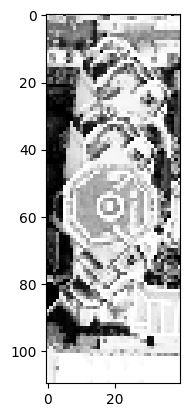

In [ ]:
#ortho
plt.imshow(ortho, cmap='Greys_r')
plt.savefig(output_file+'.jpg')
plt.show()

In [ ]:
import rasterio as rio
from rasterio.transform import from_origin
from rasterio.crs import CRS

crs = CRS.from_epsg(32647)
transform = from_origin(Emin-(GSD/2), Nmax+(GSD/2), GSD, GSD)

with rio.open( output_file+'.tif', 'w',
                driver='GTiff', height=n_row,
                 width=n_col, count=1, dtype=ortho.dtype,
                 crs=crs, transform=transform) as dst:
    dst.write(ortho,1)


Orthophoto from Right Image .... dmc 0684

In [ ]:
img_dem = '/content/DEM_Mesh.tif'
mydem = rio.open(img_dem)

img_photo = 'dmc_0684BW_32647.tif'
GSD = 1.0
myimg = rio.open(img_photo)
Emin, Emax, Nmin, Nmax = [663375, 663415, 1517560, 1517670]
output_file = 'Ortho_684_'+str(GSD)+'m'

n_col = int( (Emax-Emin)/GSD )
n_row = int( (Nmax-Nmin)/GSD )

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
# EOP Calculate from Block Bundle Adjustment
X0 =  664232.12335352
Y0 = 1517208.85420037
Z0 = 3222.27735879
om = np.radians( 0.46263903235036474 )
ph = np.radians( 3.795031160749691 )
kp = np.radians( 1.1755836705058087 )

eop = np.matrix([X0, Y0, Z0, om, ph, kp]).T

In [ ]:
ortho = np.zeros((n_row,n_col), 'uint8')
for index_row in range( 0, n_row ) :
    print('x'*(index_row+1))
    for index_col in range( 0, n_col ) :
        #print('c','r', 'E', 'N', 'H', 'DN')
        X = Emin + (index_col*GSD)
        Y = Nmax - (index_row*GSD)

        # Get 2D Ground Coordinate
        #print(n)

        # Get Height from DEM
        Z = DEM( X , Y )
        #print(Z)

        # Get 3D Ground Coordinate
        XX = np.matrix([X, Y, Z]).T

        # Retracing ... Calculate Photo Coordinate
        F = Colinearity(XX , eop , f )
        x,y = ( float(val) for val in F.A1 )

        ## convert photo coordinate from m to mm
        x = x*1000
        y = y*1000

        # Calculate Pixel Coordinate
        col = ap*x + bp*y + cp
        row = dp*x + ep*y + fp

        # Get Raster Value from Image
        DNv = DN( col, row )
        #print(index_col, index_row, X,Y,Z,DNv)
        print('.'*(index_col+1))
        ortho[index_row, index_col] = DNv

x
.
..
...
....
.....
......
.......
........
.........
..........
...........
............
.............
..............
...............
................
.................
..................
...................
....................
.....................
......................
.......................
........................
.........................
..........................
...........................
............................
.............................
..............................
...............................
................................
.................................
..................................
...................................
....................................
.....................................
......................................
.......................................
........................................
xx
.
..
...
....
.....
......
.......
........
.........
..........
...........
............
.............
..............
...............


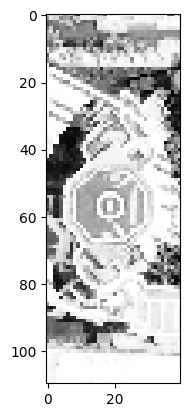

In [ ]:
#ortho
plt.imshow(ortho, cmap='Greys_r')
plt.savefig(output_file+'.jpg')
plt.show()

In [ ]:
import rasterio as rio
from rasterio.transform import from_origin
from rasterio.crs import CRS

crs = CRS.from_epsg(32647)
transform = from_origin(Emin-(GSD/2), Nmax+(GSD/2), GSD, GSD)

with rio.open( output_file+'.tif', 'w',
                driver='GTiff', height=n_row,
                 width=n_col, count=1, dtype=ortho.dtype,
                 crs=crs, transform=transform) as dst:
    dst.write(ortho,1)


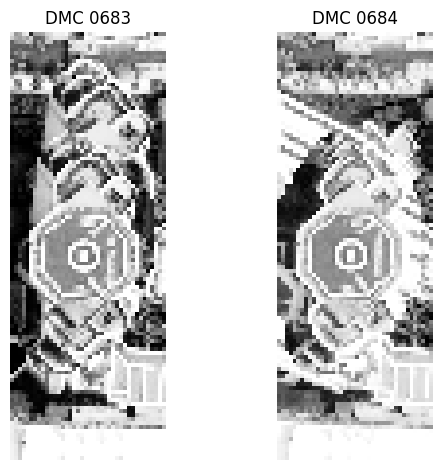

In [ ]:
with rio.open('/content/Ortho_683_1.0m.tif') as src1:
    img1 = src1.read(1)  # First band

with rio.open('/content/Ortho_684_1.0m.tif') as src2:
    img2 = src2.read(1)

plt.subplot(1, 2, 1)
plt.imshow(img1 , 'gray')
plt.title('DMC 0683')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2 , 'gray')
plt.title('DMC 0684')
plt.axis('off')

plt.tight_layout()
plt.show()